# North Atlantic Potential Intensity: 2024 seasonal analysis

This notebook computes tropical cyclone potential intensity (PI), the Genesis Potential Index (GPI), and the Ventilation Index (VI/Λ) over the **North Atlantic** from the ERA5 **2024 monthly-mean** sample (`data/sample_data.nc`). It demonstrates seasonal analyses and the log-decomposition approaches (Wing et al. 2015).

**Scope note:** the tracked sample is *regional* (North Atlantic) and subsampled to ~2° to keep the repository lean. For multi-basin or global analyses (e.g. Gilford et al. [2017](https://journals.ametsoc.org/doi/full/10.1175/JCLI-D-16-0827.1), [2019](https://journals.ametsoc.org/doi/10.1175/MWR-D-19-0021.1)), regenerate a global sample via `data/download_era5.py` (widen the `area`) and `data/build_sample_data_era5_oct2024.py`.

In [1]:
import sys
from pathlib import Path

# Locate the repo root (src/ layout) so this runs without installation.
here = Path.cwd().resolve()
repo_root = next((c for c in [here, *here.parents] if (c / "src" / "tcpyPI").is_dir()), None)
if repo_root is None:
    raise RuntimeError("Could not locate repo root (expected src/tcpyPI).")
sys.path.insert(0, str(repo_root / "src"))

import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt

from tcpyPI import pi, pi_log_decomposition, genesis_potential_index, ventilation_index
from tcpyPI import entropy_deficit_te12_from_profile
from tcpyPI.utilities import pi_efficiency, pi_diseq_resid

matplotlib.rc('font', **{'family': 'sans-serif', 'size': 13})
monlabels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
CKCD = 0.9

## 1) Load the sample and compute PI

PI is the [Bister & Emanuel (2002)](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2001JD000776) algorithm (`tcpyPI.pi`), applied over the whole grid with `xarray.apply_ufunc`.

In [2]:
ds = xr.open_dataset(repo_root / "data" / "sample_data.nc")

vmax, pmin, ifl, t0, otl = xr.apply_ufunc(
    pi, ds.sst, ds.msl, ds.p, ds.t, ds.q,
    kwargs=dict(CKCD=CKCD, ascent_flag=0, diss_flag=1, ptop=50, miss_handle=1),
    input_core_dims=[[], [], ['p'], ['p'], ['p']],
    output_core_dims=[[], [], [], [], []],
    vectorize=True,
)
DIMS = vmax.dims  # ('month', 'lat', 'lon')
print("PI computed over", dict(vmax.sizes))

PI computed over {'month': 12, 'lat': 26, 'lon': 36}


## 2) Efficiency, disequilibrium, and log-decomposition

From [Bister & Emanuel (1998)](https://texmex.mit.edu/ftp/ftp/ftp/pub/emanuel/PAPERS/bisteremanuel98.pdf), $V_{max}^2 = \frac{C_k}{C_D}\,\frac{T_s - T_0}{T_0}\,(h_0^* - h^*)$.

Taking logs ([Wing et al. 2015](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2015GL066145)):

$$2\ln V_{max} = \ln\frac{C_k}{C_D} + \ln\frac{T_s - T_0}{T_0} + \ln(h_0^* - h^*).$$

In [3]:
sstK = ds.sst + 273.15  # efficiency/decomposition need absolute temperature

eff = xr.apply_ufunc(pi_efficiency, sstK, t0,
    input_core_dims=[[], []], output_core_dims=[[]], vectorize=True)
diseq = xr.apply_ufunc(pi_diseq_resid, vmax, sstK, t0, kwargs=dict(CKCD=CKCD),
    input_core_dims=[[], [], []], output_core_dims=[[]], vectorize=True)
lnpi, lneff, lndiseq, lnCKCD = xr.apply_ufunc(
    pi_log_decomposition, vmax, sstK, t0, kwargs=dict(CKCD=CKCD, sst_units="K"),
    input_core_dims=[[], [], []], output_core_dims=[[], [], [], []], vectorize=True)
print("efficiency / disequilibrium / log-decomposition computed")

efficiency / disequilibrium / log-decomposition computed


## 3) Genesis Potential Index (GPI) and Ventilation Index (VI)

We compute both seasonally from the sample fields:

- **GPI (`en04`)**: from low-level absolute vorticity $|\eta|=|f+\zeta_{850}|$, midlevel RH (700 hPa), 850–200 hPa shear, and PI.
- **VI (Λ, TE12)**: $\Lambda = (u_{shear}/V_{PI})\,\chi_m$, where $\chi_m$ is the midlevel (600 hPa) moist-entropy deficit computed per column with `entropy_deficit_te12_from_profile`.

In [4]:
def _align(da):
    return da.transpose(*DIMS)

# deep-layer shear (850-200 hPa), low-level absolute vorticity, midlevel RH
shear = _align(np.hypot(ds.u.sel(p=850, drop=True) - ds.u.sel(p=200, drop=True),
                        ds.v.sel(p=850, drop=True) - ds.v.sel(p=200, drop=True)))
f = 2 * 7.292115e-5 * np.sin(np.deg2rad(ds.lat))       # Coriolis parameter
abs_vort = _align(np.abs(f + ds.vo.sel(p=850, drop=True)))   # |f + zeta| at 850 hPa
rh700 = _align(ds.r.sel(p=700, drop=True))

# GPI (en04): genesis_potential_index broadcasts, so compute on values and rewrap
gpi = xr.DataArray(
    genesis_potential_index(abs_vort.values, rh700.values, shear.values, vmax.values,
                            formulation="en04"),
    coords=vmax.coords, dims=DIMS, name="gpi")

# VI: chi_m per column (skip land where SST is NaN), then Lambda
def _chi_col(P, T, q, SST, MSL):
    if not np.isfinite(SST):
        return np.nan
    return entropy_deficit_te12_from_profile(
        P, T, q, T_units="C", q_units="g/kg", SST=SST, SST_units="C",
        psfc_hpa=MSL, T2m=T[0], q2m=q[0], p_mid_hpa=600.0)

chi = _align(xr.apply_ufunc(_chi_col, ds.p, ds.t, ds.q, ds.sst, ds.msl,
    input_core_dims=[['p'], ['p'], ['p'], [], []], output_core_dims=[[]], vectorize=True))
vi = xr.DataArray(ventilation_index(shear.values, vmax.values, chi.values),
                  coords=vmax.coords, dims=DIMS, name="vi")
print("GPI and VI computed")

GPI and VI computed


In [5]:
full = xr.Dataset(dict(
    sst=ds.sst, t0=t0, otl=otl, ifl=ifl, vmax=vmax, pmin=pmin,
    eff=eff, diseq=diseq, lnpi=lnpi, lneff=lneff, lndiseq=lndiseq,
    shear=shear, abs_vort=abs_vort, rh700=rh700, chi=chi, gpi=gpi, vi=vi,
))
weights = np.cos(np.deg2rad(full.lat))   # latitude weighting for domain means
lnCKCD_val = float(np.log(CKCD))

## 4) Annual climatology (2024 mean maps)

<>:16: SyntaxWarning: invalid escape sequence '\L'
<>:16: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_2776161/1913304039.py:16: SyntaxWarning: invalid escape sequence '\L'
  mapplot(full.vi, "Annual-mean ventilation index $\Lambda$", cmap="YlGnBu")


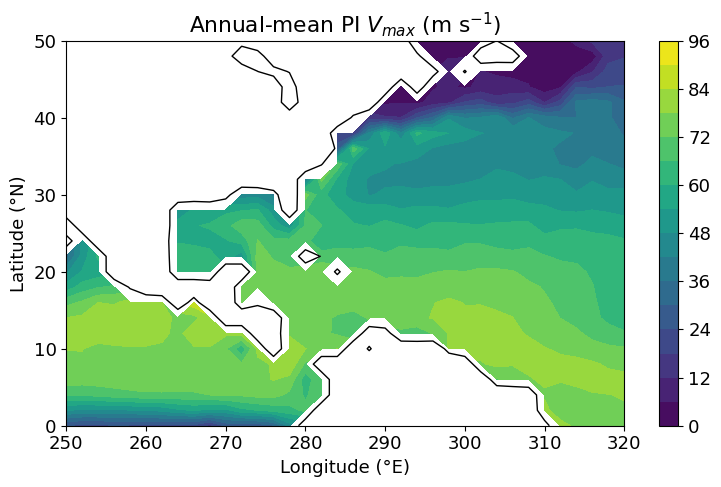

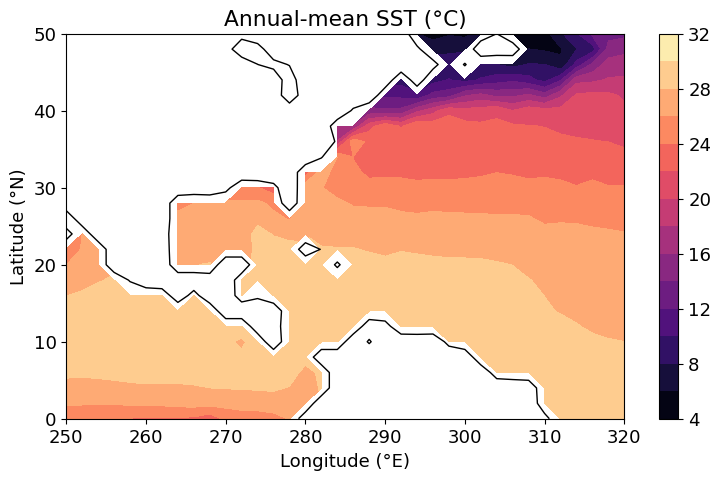

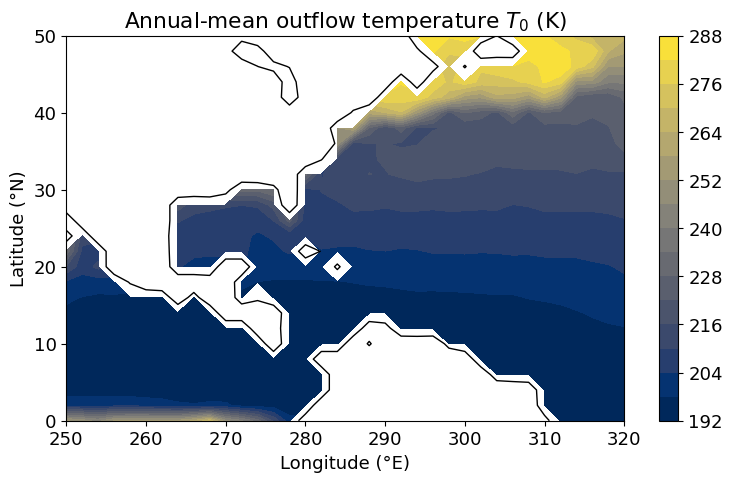

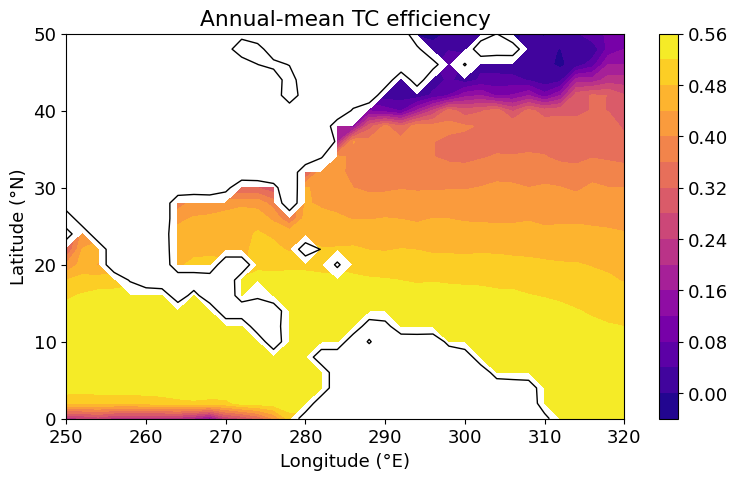

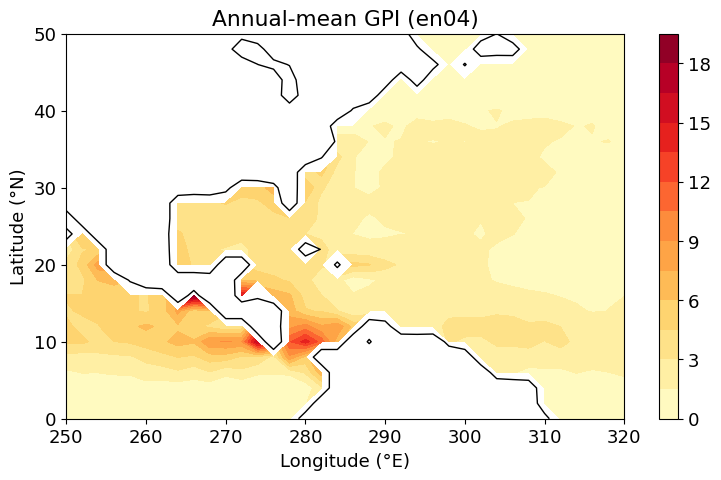

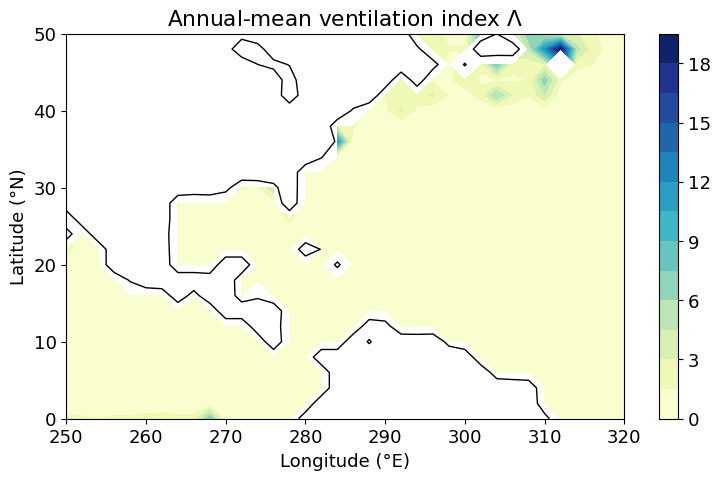

In [6]:
def mapplot(field, title, cmap="viridis"):
    plt.figure(figsize=(9, 5))
    plt.contourf(full.lon, full.lat, field.mean("month"), levels=15, cmap=cmap)
    plt.colorbar()
    plt.contour(ds.lon, ds.lat, ds.lsm, [0.5], colors="k", linewidths=1)  # coastline
    plt.xlabel("Longitude (°E)")
    plt.ylabel("Latitude (°N)")
    plt.title(title)
    plt.show()

mapplot(full.vmax, "Annual-mean PI $V_{max}$ (m s$^{-1}$)")
mapplot(full.sst, "Annual-mean SST (°C)", cmap="magma")
mapplot(full.t0, "Annual-mean outflow temperature $T_0$ (K)", cmap="cividis")
mapplot(full.eff, "Annual-mean TC efficiency", cmap="plasma")
mapplot(full.gpi, "Annual-mean GPI (en04)", cmap="YlOrRd")
mapplot(full.vi, "Annual-mean ventilation index $\Lambda$", cmap="YlGnBu")

## 5) Seasonal cycle (domain mean, latitude-weighted)

### PI, SSTs, and efficiency

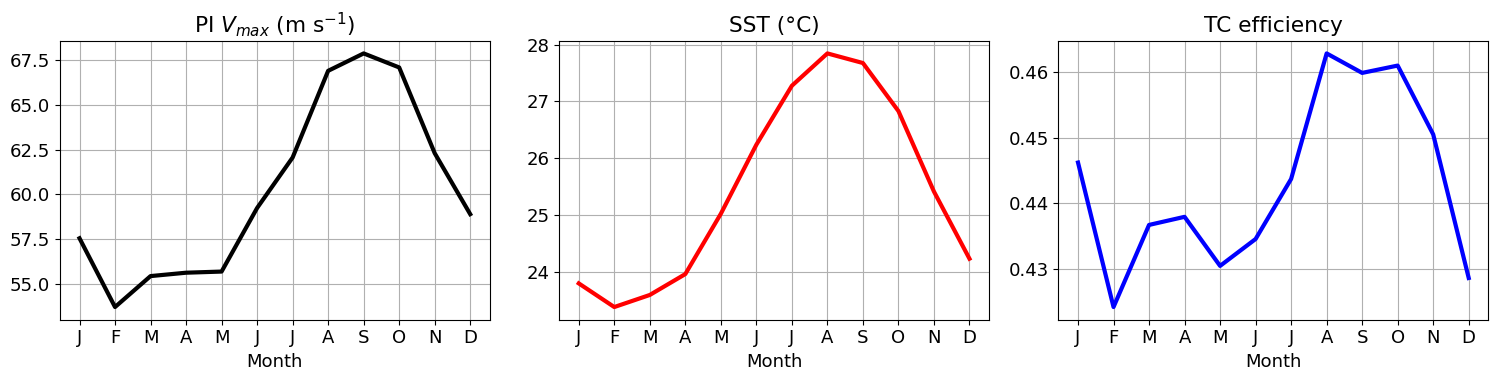

In [7]:
def seascycle(field):
    return np.array([float(field.sel(month=m).weighted(weights).mean(("lat", "lon")))
                     for m in range(1, 13)])

mon = np.arange(1, 13)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (fld, ttl, c) in zip(ax, [(full.vmax, "PI $V_{max}$ (m s$^{-1}$)", "k"),
                                  (full.sst, "SST (°C)", "r"),
                                  (full.eff, "TC efficiency", "b")]):
    a.plot(mon, seascycle(fld), c, lw=3)
    a.set_xticks(mon); a.set_xticklabels(monlabels); a.grid(); a.set_title(ttl); a.set_xlabel("Month")
plt.tight_layout(); plt.show()

### GPI and VI

The Atlantic hurricane-season signal is clear: **GPI peaks in late summer/early autumn** while the **ventilation index drops** (low ventilation = favorable) over the same months.

<>:3: SyntaxWarning: invalid escape sequence '\L'
<>:3: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_2776161/2319821503.py:3: SyntaxWarning: invalid escape sequence '\L'
  ax[1].plot(mon, seascycle(full.vi), "m", lw=3); ax[1].set_title("Ventilation Index $\Lambda$")


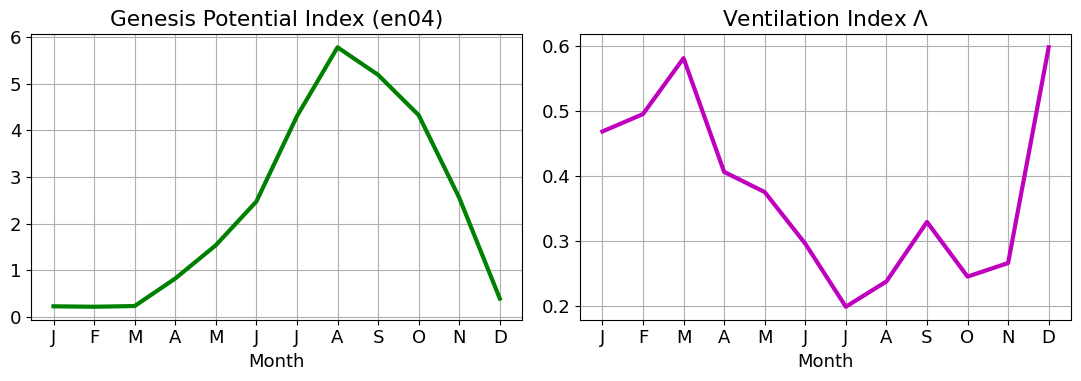

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(mon, seascycle(full.gpi), "g", lw=3); ax[0].set_title("Genesis Potential Index (en04)")
ax[1].plot(mon, seascycle(full.vi), "m", lw=3); ax[1].set_title("Ventilation Index $\Lambda$")
for a in ax:
    a.set_xticks(mon); a.set_xticklabels(monlabels); a.grid(); a.set_xlabel("Month")
plt.tight_layout(); plt.show()

## 6) Seasonal amplitude of the PI decomposition

The peak-to-peak seasonal range of each log term shows what drives the PI seasonal cycle (cf. Gilford et al. 2017, Table 2). $\ln(C_k/C_D)$ is constant.

Domain-mean seasonal amplitude (peak-to-peak):
  lnpi     = 0.544
  lneff    = 0.104
  lndiseq  = 0.419
  lnCKCD   = -0.105 (constant)


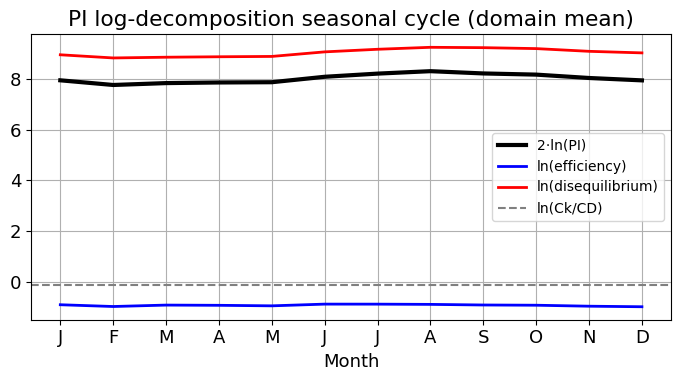

In [9]:
terms = {k: seascycle(full[k]) for k in ["lnpi", "lneff", "lndiseq"]}
amp = {k: float(np.ptp(v)) for k, v in terms.items()}
print("Domain-mean seasonal amplitude (peak-to-peak):")
for k, v in amp.items():
    print(f"  {k:8s} = {v:.3f}")
print(f"  lnCKCD   = {lnCKCD_val:.3f} (constant)")

plt.figure(figsize=(7, 4))
plt.plot(mon, terms["lnpi"], "k", lw=3, label="2·ln(PI)")
plt.plot(mon, terms["lneff"], "b", lw=2, label="ln(efficiency)")
plt.plot(mon, terms["lndiseq"], "r", lw=2, label="ln(disequilibrium)")
plt.axhline(lnCKCD_val, ls="--", color="gray", label="ln(Ck/CD)")
plt.xticks(mon, monlabels); plt.grid(); plt.legend(fontsize=10)
plt.xlabel("Month"); plt.title("PI log-decomposition seasonal cycle (domain mean)")
plt.tight_layout(); plt.show()

## 7) Ventilation index decomposition

Λ is multiplicative (TE12), so in log space it separates into additive contributions:

$$\ln\Lambda = \ln u_{shear} - \ln V_{PI} + \ln\chi_m.$$

The seasonal cycle of each term shows what drives Λ's seasonality.

VI decomposition closure, max|resid| = 0.0


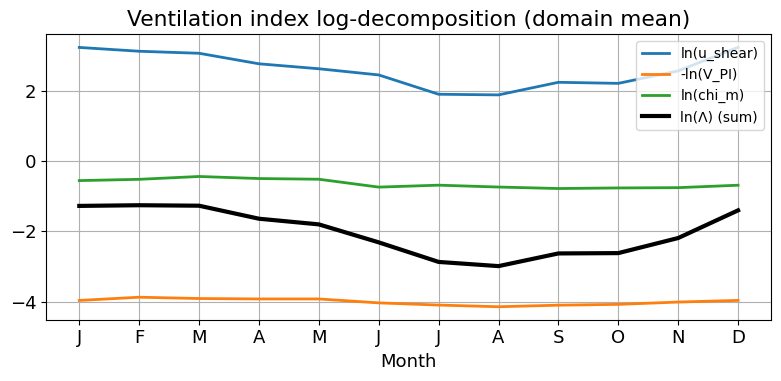

In [10]:
# Library API: tcpyPI.vi_log_decomposition returns the additive contributions
# (shear, pi, chi) that sum to ln(Lambda). Wrap them back into DataArrays.
from tcpyPI import vi_log_decomposition
def _wrap(a):
    return xr.DataArray(a, coords=full.vmax.coords, dims=full.vmax.dims)

vdec = vi_log_decomposition(full.shear, full.vmax, full.chi)
vi_terms = {
    "ln(u_shear)": _wrap(vdec["shear"]),
    "-ln(V_PI)":   _wrap(vdec["pi"]),
    "ln(chi_m)":   _wrap(vdec["chi"]),
}
lnvi = _wrap(vdec["lnvi"])
# closure check: the contributions should sum to ln(Lambda)
_resid = seascycle(sum(vi_terms.values())) - seascycle(lnvi)
print("VI decomposition closure, max|resid| =", float(np.max(np.abs(_resid))))

plt.figure(figsize=(8, 4))
for lab, fld in vi_terms.items():
    plt.plot(mon, seascycle(fld), lw=2, label=lab)
plt.plot(mon, seascycle(lnvi), "k", lw=3, label="ln(Λ) (sum)")
plt.xticks(mon, monlabels); plt.grid(); plt.legend(fontsize=10)
plt.xlabel("Month"); plt.title("Ventilation index log-decomposition (domain mean)")
plt.tight_layout(); plt.show()

## 8) Genesis potential index decomposition (en04)

The `en04` GPI is also multiplicative, so it decomposes additively in log space:

$$\ln\mathrm{GPI} = \tfrac{3}{2}\ln(10^5|\eta|) + 3\ln\tfrac{RH}{50} + 3\ln\tfrac{V_{PI}}{70} - 2\ln(1+0.1\,V_{shear}).$$

This reveals which factor (vorticity, humidity, PI, or shear) drives the GPI seasonal cycle.

GPI decomposition closure, max|resid| = 0.0


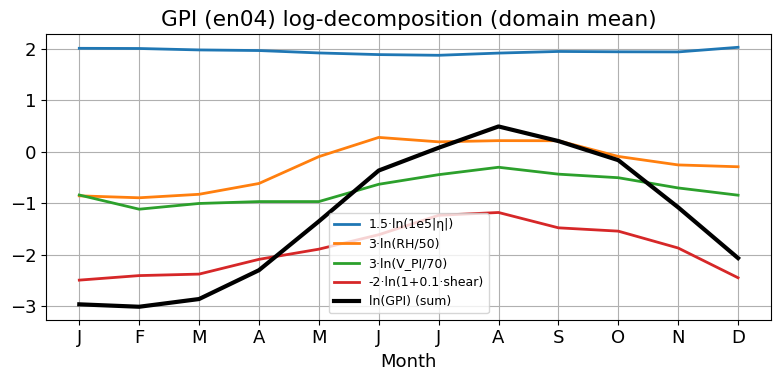

In [11]:
# Library API: tcpyPI.gpi_log_decomposition returns the additive contributions
# (vorticity, humidity, pi, shear) that sum to ln(GPI).
from tcpyPI import gpi_log_decomposition

gdec = gpi_log_decomposition(full.abs_vort, rh_mid=full.rh700, v_shear=full.shear,
                             v_pot=full.vmax, formulation="en04")
gpi_terms = {
    "1.5·ln(1e5|η|)":     _wrap(gdec["vorticity"]),
    "3·ln(RH/50)":        _wrap(gdec["humidity"]),
    "3·ln(V_PI/70)":      _wrap(gdec["pi"]),
    "-2·ln(1+0.1·shear)": _wrap(gdec["shear"]),
}
lngpi = _wrap(gdec["lngpi"])
_resid = seascycle(sum(gpi_terms.values())) - seascycle(lngpi)
print("GPI decomposition closure, max|resid| =", float(np.max(np.abs(_resid))))

plt.figure(figsize=(8, 4))
for lab, fld in gpi_terms.items():
    plt.plot(mon, seascycle(fld), lw=2, label=lab)
plt.plot(mon, seascycle(lngpi), "k", lw=3, label="ln(GPI) (sum)")
plt.xticks(mon, monlabels); plt.grid(); plt.legend(fontsize=9)
plt.xlabel("Month"); plt.title("GPI (en04) log-decomposition (domain mean)")
plt.tight_layout(); plt.show()

## Conclusion

Over the North Atlantic in 2024, PI, GPI, and the ventilation index all express the hurricane-season cycle: PI and genesis potential peak in late summer while ventilation is in its valley. The log-decomposition attributes the PI seasonal cycle to its efficiency and disequilibrium components.

This demonstrates the tracked, regional 2024 sample. For multi-basin/global work, regenerate a wider sample (see the scope note at the top).